# Predicting Unemployment in Developing Countries
### Summative Assessment Education & Job Creation

For this project, I wanted to explore what drives unemployment in developing countries specifically, whether things like education spending, literacy rates, school enrollment, and economic indicators can help predict a country's unemployment rate. I focused on developing nations (low and middle-income countries) because that's where education investment arguably matters most for job creation, and it ties into my GCGO around Education and Job Creation.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_style('whitegrid')
print('Libraries loaded.')

Libraries loaded.


## Loading and Exploring the Raw Data

The dataset I'm using is the World Bank Education Statistics (EdStats) from Kaggle. It's a massive dataset, over 886K rows, where each row is one indicator for one country, and the year columns hold the actual values. So it's in a "long" format that I'll need to reshape later.

I also need to filter for developing countries only, so I'll load the country metadata file too.

In [2]:
import os

# if the cleaned dataset already exists, we can skip the heavy raw data loading
# this makes it easy to re-run without the 326MB raw file
USE_CACHED = os.path.exists('data/cleaned_data.csv')

if not USE_CACHED:
    # load the main data and the country metadata
    df_raw = pd.read_csv('data/EdStatsData.csv')
    df_country = pd.read_csv('data/EdStatsCountry.csv')

    print(f'Raw data: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns')
    print(f'Unique countries: {df_raw["Country Name"].nunique()}')
    print(f'Unique indicators: {df_raw["Indicator Name"].nunique()}')
    display(df_raw.head())
else:
    df_country = pd.read_csv('data/EdStatsCountry.csv')
    print('Found cleaned dataset — skipping raw data loading')
    print('(To re-process from scratch, delete data/cleaned_data.csv and re-run)')

Found cleaned dataset — skipping raw data loading
(To re-process from scratch, delete data/cleaned_data.csv and re-run)


In [3]:
if not USE_CACHED:
    # let's see what the data looks like — each row is one indicator for one country
    # the actual values are spread across year columns (1970, 1971, ... 2017)
    print('Columns:', df_raw.columns.tolist()[:10], '...')
    print(f'\nFirst few indicator names:')
    for ind in df_raw['Indicator Name'].unique()[:10]:
        print(f'  - {ind}')
else:
    print('Skipped — using cached cleaned data')

Skipped — using cached cleaned data


So the structure makes sense. it's a panel dataset in long format. Each row is one indicator for one country, and each year column has that indicator's value for that year. I'll need to pick the indicators that i'll use, melt the years into rows, then pivot so each indicator becomes its own column.

## Filtering for Developing Countries & Reshaping

First, I need to filter the data to only include developing countries. The `EdStatsCountry.csv` file has an "Income Group" column that classifies countries. I'll keep low-income, lower-middle-income, and upper-middle-income countries, basically everything except high-income OECD and non-OECD.

In [4]:
if not USE_CACHED:
    # check what income groups exist
    print(df_country['Income Group'].value_counts(dropna=False))

    # get country codes for developing nations only
    developing_groups = ['Low income', 'Lower middle income', 'Upper middle income']
    dev_countries = df_country[df_country['Income Group'].isin(developing_groups)]['Country Code'].tolist()
    print(f'\nDeveloping country codes: {len(dev_countries)}')

    # filter the raw data to only developing countries
    df_raw = df_raw[df_raw['Country Code'].isin(dev_countries)]
    print(f'After filtering to developing countries: {df_raw.shape}')
else:
    print('Skipped — using cached cleaned data')

Skipped — using cached cleaned data


Now I'll pick the indicators I want to use. My target variable is the total unemployment rate (`SL.UEM.TOTL.ZS`), and I've chosen a mix of education and economic features that I think could be good predictors.

In [5]:
if not USE_CACHED:
    # All the indicators i'll extracting
    # target: total unemployment rate (% of labor force)
    # features: education spending, literacy, enrollment, economic factors
    indicators = {
        'SL.UEM.TOTL.ZS': 'Unemployment_Rate',
        'SE.XPD.TOTL.GD.ZS': 'Govt_Education_Spending_GDP_Pct',
        'SE.XPD.TOTL.GB.ZS': 'Govt_Education_Spending_Govt_Pct',
        'SE.ADT.LITR.ZS': 'Literacy_Rate_Adult',
        'SE.ADT.LITR.FE.ZS': 'Literacy_Rate_Female',
        'SE.ADT.LITR.MA.ZS': 'Literacy_Rate_Male',
        'SE.PRM.ENRR': 'School_Enrollment_Primary',
        'SE.SEC.ENRR': 'School_Enrollment_Secondary',
        'SE.TER.ENRR': 'School_Enrollment_Tertiary',
        'SE.PRM.CMPT.ZS': 'Primary_Completion_Rate',
        'SE.SEC.CMPT.LO.ZS': 'Lower_Secondary_Completion_Rate',
        'SE.PRM.TCHR': 'Primary_Teachers',
        'SE.SEC.TCHR': 'Secondary_Teachers',
        'SE.PRM.ENRL.TC.ZS': 'Pupil_Teacher_Ratio_Primary',
        'SE.SEC.ENRL.TC.ZS': 'Pupil_Teacher_Ratio_Secondary',
        'NY.GDP.PCAP.CD': 'GDP_Per_Capita',
        'SP.POP.TOTL': 'Population_Total',
        'SP.POP.1564.TO.ZS': 'Population_15_64_Pct',
        'SL.TLF.TOTL.IN': 'Labor_Force_Total',
        'SL.TLF.TOTL.FE.ZS': 'Labor_Force_Female_Pct',
        'SL.TLF.ADVN.ZS': 'Labor_Force_Advanced_Education',
        'SL.TLF.BASC.ZS': 'Labor_Force_Basic_Education',
        'SL.TLF.INTM.ZS': 'Labor_Force_Intermediate_Education',
        'SL.UEM.NEET.ZS': 'NEET_Rate',
    }

    available_codes = df_raw['Indicator Code'].unique()
    found = {k: v for k, v in indicators.items() if k in available_codes}
    missing = {k: v for k, v in indicators.items() if k not in available_codes}

    print(f'Found {len(found)}/{len(indicators)} indicators')
    if missing:
        print(f'Missing: {list(missing.values())}')
else:
    print('Skipped — using cached cleaned data')

Skipped — using cached cleaned data


In [6]:
if not USE_CACHED:
    # filter to only the indicators i'll need
    df_filtered = df_raw[df_raw['Indicator Code'].isin(found.keys())].copy()
    print(f'Filtered to selected indicators: {df_filtered.shape}')

    # figure out which columns are years
    year_cols = [col for col in df_filtered.columns if col.isdigit()]
    print(f'Year columns: {year_cols[0]} to {year_cols[-1]} ({len(year_cols)} years)')
else:
    print('Skipped — using cached cleaned data')

Skipped — using cached cleaned data


In [7]:
if not USE_CACHED:
    # melt: turn year columns into rows
    # before: each year is a separate column
    # after: one "Year" column and one "Value" column
    id_cols = ['Country Name', 'Country Code', 'Indicator Code']
    df_melted = df_filtered.melt(
        id_vars=id_cols,
        value_vars=year_cols,
        var_name='Year',
        value_name='Value'
    )
    df_melted['Year'] = df_melted['Year'].astype(int)
    df_melted.dropna(subset=['Value'], inplace=True)
    print(f'After melting: {df_melted.shape}')
    df_melted.head()
else:
    print('Skipped — using cached cleaned data')

Skipped — using cached cleaned data


In [8]:
if not USE_CACHED:
    # pivot: turn each indicator into its own column
    # so each row becomes one country in one year, with all indicators as columns
    df_pivot = df_melted.pivot_table(
        index=['Country Name', 'Country Code', 'Year'],
        columns='Indicator Code',
        values='Value',
        aggfunc='first'
    ).reset_index()

    df_pivot.columns.name = None
    df_pivot.rename(columns=found, inplace=True)

    print(f'After pivoting: {df_pivot.shape}')
    df_pivot.head()
else:
    print('Skipped — using cached cleaned data')

Skipped — using cached cleaned data


In [9]:
if not USE_CACHED:
    # drop rows where unemployment rate (target) is missing — can't train without it
    print(f'Before dropping missing target: {df_pivot.shape[0]} rows')
    df_clean = df_pivot.dropna(subset=['Unemployment_Rate']).copy()
    print(f'After dropping missing target: {df_clean.shape[0]} rows')
else:
    print('Skipped — using cached cleaned data')

Skipped — using cached cleaned data


In [10]:
if not USE_CACHED:
    # handle missing values in the features
    # forward-fill within each country (carry last known value forward),
    # then backward-fill for any leading NaNs, then median for anything still missing
    feature_cols = [col for col in df_clean.columns if col not in ['Country Name', 'Country Code', 'Year']]

    df_clean.loc[:, feature_cols] = df_clean.groupby('Country Name')[feature_cols].transform(
        lambda x: x.ffill().bfill()
    )

    for col in feature_cols:
        median_val = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_val)

    print('Missing values after cleaning:')
    print(df_clean[feature_cols].isnull().sum())
    print(f'\nCleaned dataset: {df_clean.shape}')
else:
    print('Skipped — using cached cleaned data')

Skipped — using cached cleaned data


In [11]:
if not USE_CACHED:
    print(f'Countries: {df_clean["Country Name"].nunique()}')
    print(f'Year range: {df_clean["Year"].min()} - {df_clean["Year"].max()}')
    print(f'Features: {len(feature_cols)}')
    print()
    df_clean.head()
else:
    print('Skipped — using cached cleaned data')

Skipped — using cached cleaned data


In [12]:
if not USE_CACHED:
    df_clean.describe()
else:
    print('Skipped — using cached cleaned data')

Skipped — using cached cleaned data


In [13]:
if not USE_CACHED:
    # save the cleaned dataset so anyone can re-run the notebook
    # without needing the massive 326MB raw file
    df_clean.to_csv('data/cleaned_data.csv', index=False)
    print(f'Cleaned dataset saved to data/cleaned_data.csv ({df_clean.shape[0]} rows x {df_clean.shape[1]} cols)')
else:
    # load the cleaned dataset from cache
    df_clean = pd.read_csv('data/cleaned_data.csv')
    feature_cols = [col for col in df_clean.columns if col not in ['Country Name', 'Country Code', 'Year']]
    print(f'Loaded cleaned dataset: {df_clean.shape[0]} rows x {df_clean.shape[1]} cols')
    print(f'Countries: {df_clean["Country Name"].nunique()}')
    print(f'Year range: {df_clean["Year"].min()} - {df_clean["Year"].max()}')
    df_clean.head()

Loaded cleaned dataset: 3328 rows x 27 cols


Countries: 128
Year range: 1991 - 2016


After all the reshaping and cleaning, I've got a panel dataset where each row is one developing country in one year. The features cover education spending, literacy, school enrollment, teacher ratios, and economic indicators. The target is the total unemployment rate.

## Exploring the Data (EDA)

Before training any models, I want to understand what the data looks like and how the features relate to unemployment.

### Correlation Heatmap

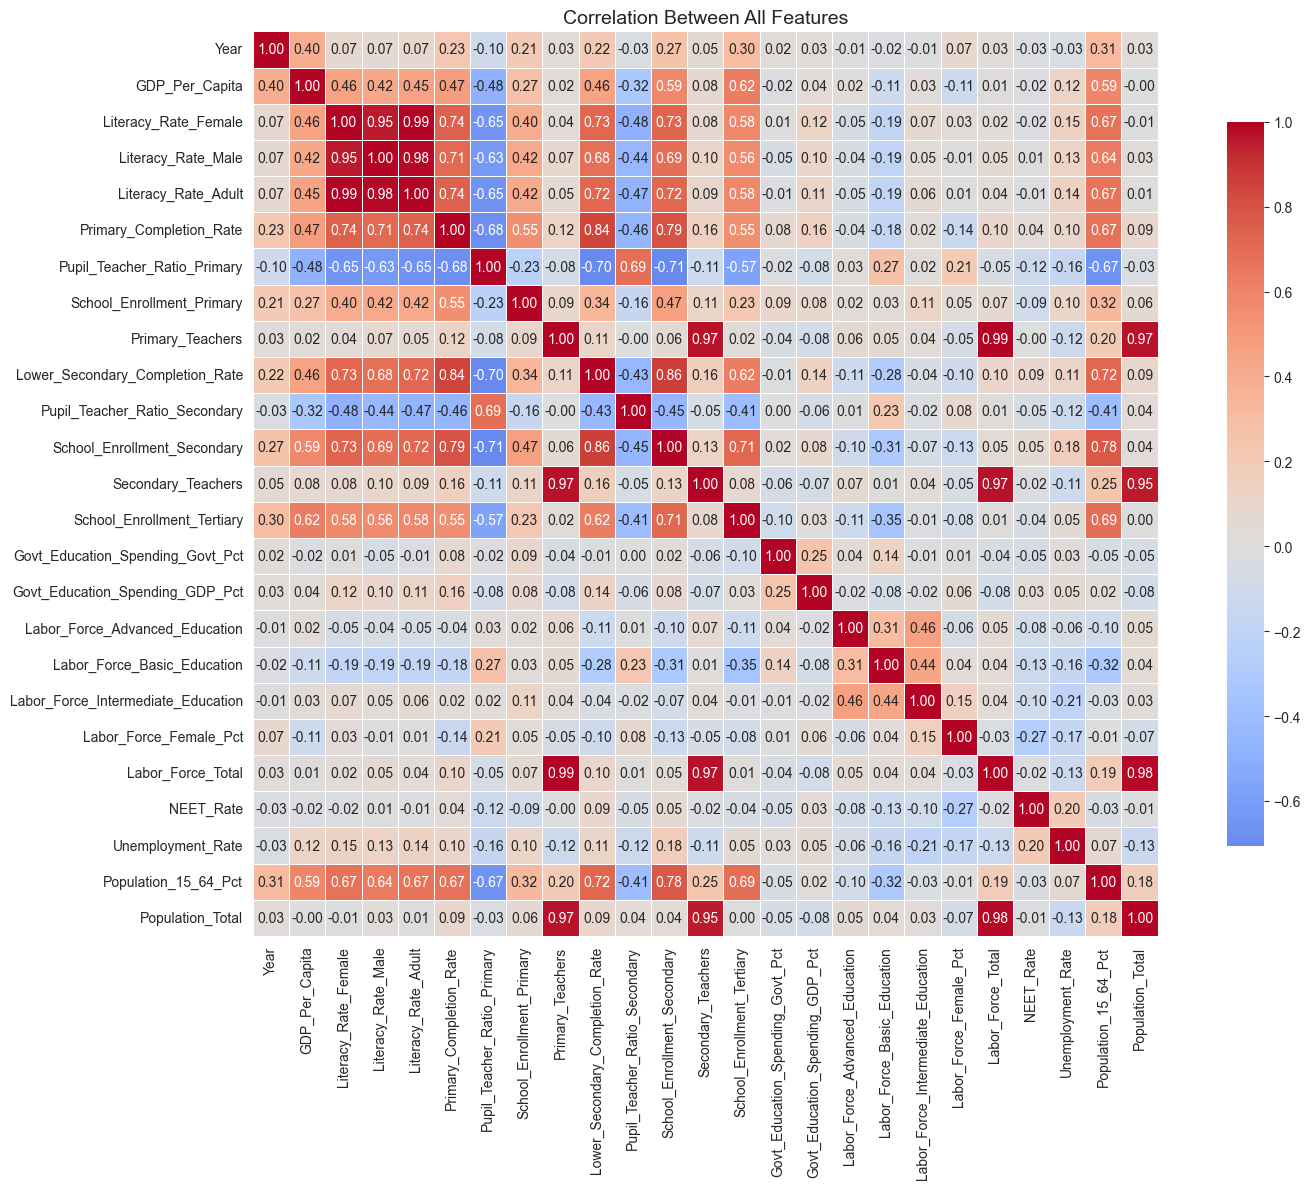

Heatmap saved.


In [14]:
# let's see how all the numeric features correlate with each other and with unemployment
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df_clean[numeric_cols].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Between All Features', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()
print('Heatmap saved.')

Looking at the heatmap, a few things jump out. The literacy rates (male, female, adult) are all very tightly correlated with each other, which makes sense, they're measuring similar things. GDP per capita has some interesting relationships too. The correlations with unemployment aren't super strong for most individual features, which tells me that this is a genuinely multivariate problem, no single feature is going to predict unemployment on its own.

### Distribution of Key Variables

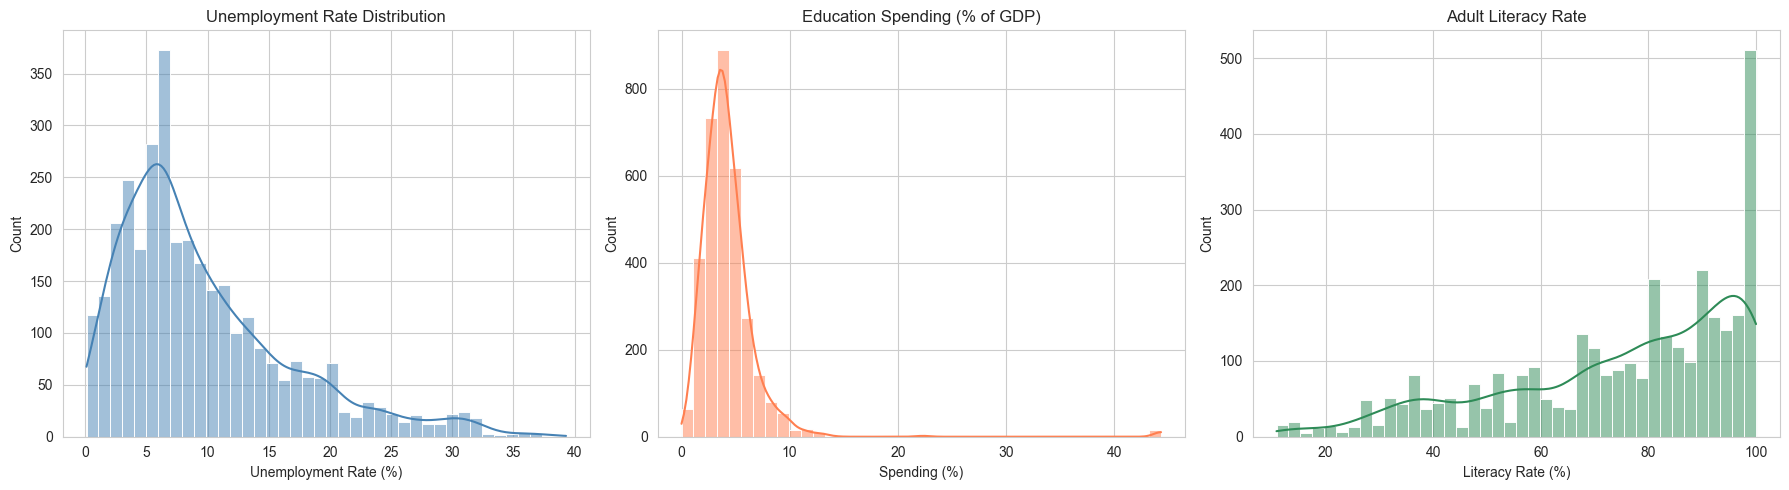

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# unemployment rate
sns.histplot(df_clean['Unemployment_Rate'], kde=True, ax=axes[0], color='steelblue', bins=40)
axes[0].set_title('Unemployment Rate Distribution')
axes[0].set_xlabel('Unemployment Rate (%)')

# education spending
if 'Govt_Education_Spending_GDP_Pct' in df_clean.columns:
    sns.histplot(df_clean['Govt_Education_Spending_GDP_Pct'].dropna(), kde=True, ax=axes[1], color='coral', bins=40)
    axes[1].set_title('Education Spending (% of GDP)')
    axes[1].set_xlabel('Spending (%)')

# literacy rate
if 'Literacy_Rate_Adult' in df_clean.columns:
    sns.histplot(df_clean['Literacy_Rate_Adult'].dropna(), kde=True, ax=axes[2], color='seagreen', bins=40)
    axes[2].set_title('Adult Literacy Rate')
    axes[2].set_xlabel('Literacy Rate (%)')

plt.tight_layout()
plt.savefig('distributions.png', dpi=100, bbox_inches='tight')
plt.show()

The unemployment distribution is right-skewed, most developing countries sit between 3-15%, but there are some outliers with much higher rates. Education spending clusters around 3-6% of GDP, which seems typical. Literacy rates are all over the place, from under 30% to nearly 100%, which makes sense given we're looking at a wide range of developing countries.

### Scatter Plots  Features Most Correlated with Unemployment

Top 3 correlated features:
  Labor_Force_Intermediate_Education: -0.207
  NEET_Rate: 0.203
  School_Enrollment_Secondary: 0.177


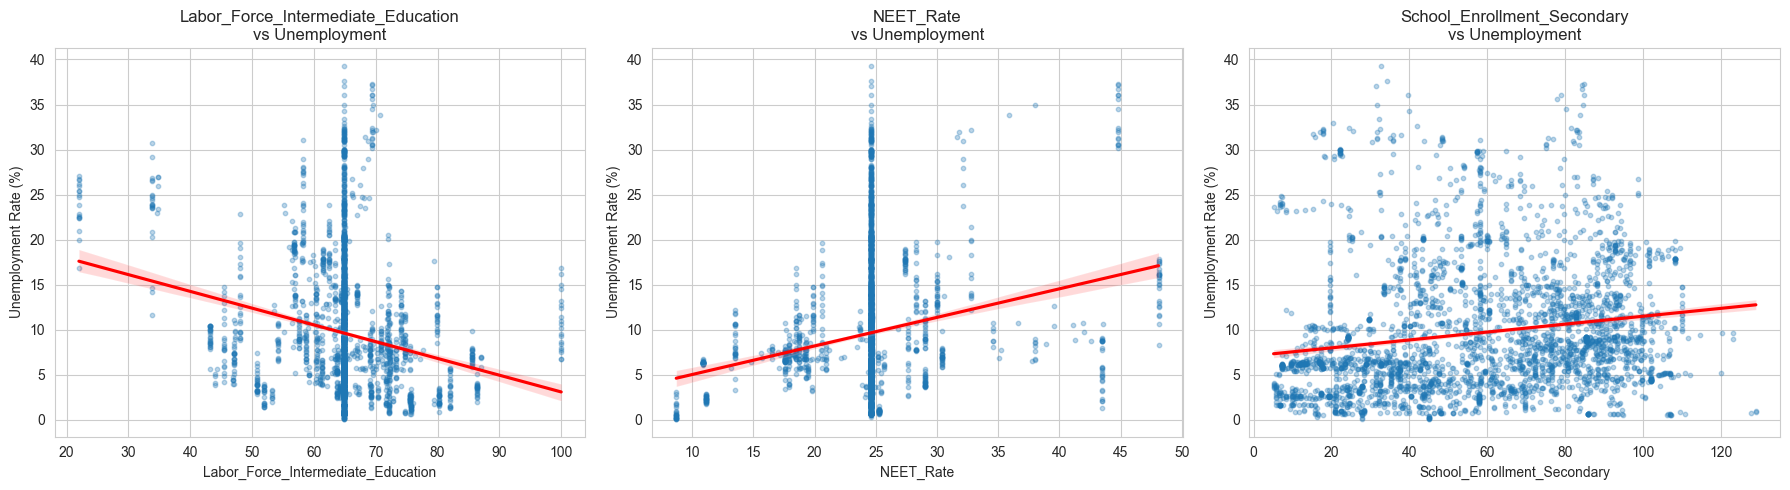

In [16]:
# find the top 3 features most correlated with unemployment
target_corr = corr_matrix['Unemployment_Rate'].drop('Unemployment_Rate').abs().sort_values(ascending=False)
top_3_features = target_corr.head(3).index.tolist()
print('Top 3 correlated features:')
for feat in top_3_features:
    print(f'  {feat}: {corr_matrix["Unemployment_Rate"][feat]:.3f}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, feat in enumerate(top_3_features):
    sns.regplot(x=feat, y='Unemployment_Rate', data=df_clean,
                ax=axes[i], scatter_kws={'alpha': 0.3, 's': 10}, line_kws={'color': 'red'})
    axes[i].set_title(f'{feat}\nvs Unemployment')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Unemployment Rate (%)')

plt.tight_layout()
plt.savefig('scatter_top3.png', dpi=100, bbox_inches='tight')
plt.show()

The scatter plots show there are visible trends, but they're not super tightm, lots of spread around the regression lines. This confirms that predicting unemployment needs multiple features working together. The trend lines at least show the direction of each relationship, which will help the model.

### Unemployment by Region

In [17]:
# merge region info from the country metadata
region_info = df_country[['Country Code', 'Region']].dropna()
region_info = region_info[region_info['Region'] != '']

df_with_region = df_clean.merge(region_info, on='Country Code', how='left')
df_with_region = df_with_region.dropna(subset=['Region'])
df_with_region = df_with_region[df_with_region['Region'] != '']

print(f'Regions found: {df_with_region["Region"].nunique()}')
print(df_with_region['Region'].value_counts())

Regions found: 6
Region
Sub-Saharan Africa            1170
Latin America & Caribbean      624
Europe & Central Asia          520
East Asia & Pacific            468
Middle East & North Africa     338
South Asia                     208
Name: count, dtype: int64


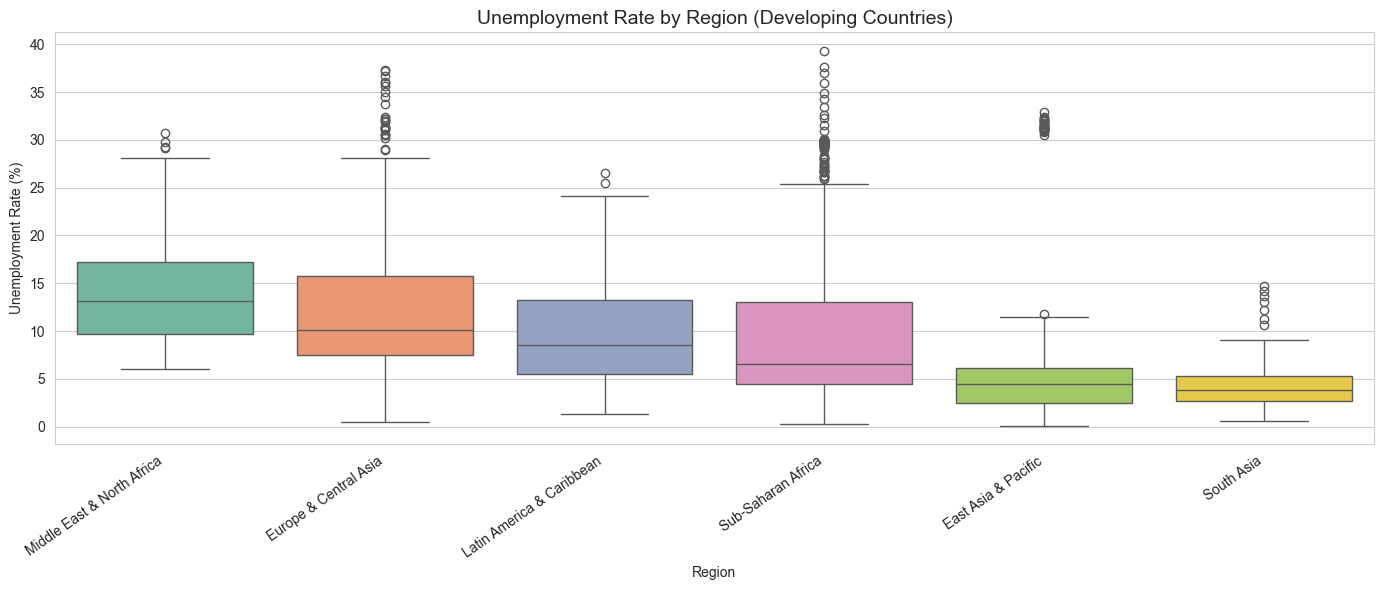

In [18]:
plt.figure(figsize=(14, 6))
order = df_with_region.groupby('Region')['Unemployment_Rate'].median().sort_values(ascending=False).index
sns.boxplot(x='Region', y='Unemployment_Rate', data=df_with_region, order=order, palette='Set2')
plt.xticks(rotation=35, ha='right')
plt.title('Unemployment Rate by Region (Developing Countries)', fontsize=14)
plt.xlabel('Region')
plt.ylabel('Unemployment Rate (%)')
plt.tight_layout()
plt.savefig('boxplot_regions.png', dpi=100, bbox_inches='tight')
plt.show()

There are pretty clear regional differences. Some regions have much higher median unemployment and wider spreads. This tells me that adding region as a feature could help the model, it captures geographic and structural economic differences that the other indicators might not fully explain on their own.

## Feature Engineering

Now I need to decide which columns to keep, drop, or transform before training.

In [19]:
# I'll use the version with region info for modeling
df_model = df_with_region.copy()
print(f'Starting shape: {df_model.shape}')
print(f'Columns: {df_model.columns.tolist()}')

Starting shape: (3328, 28)
Columns: ['Country Name', 'Country Code', 'Year', 'GDP_Per_Capita', 'Literacy_Rate_Female', 'Literacy_Rate_Male', 'Literacy_Rate_Adult', 'Primary_Completion_Rate', 'Pupil_Teacher_Ratio_Primary', 'School_Enrollment_Primary', 'Primary_Teachers', 'Lower_Secondary_Completion_Rate', 'Pupil_Teacher_Ratio_Secondary', 'School_Enrollment_Secondary', 'Secondary_Teachers', 'School_Enrollment_Tertiary', 'Govt_Education_Spending_Govt_Pct', 'Govt_Education_Spending_GDP_Pct', 'Labor_Force_Advanced_Education', 'Labor_Force_Basic_Education', 'Labor_Force_Intermediate_Education', 'Labor_Force_Female_Pct', 'Labor_Force_Total', 'NEET_Rate', 'Unemployment_Rate', 'Population_15_64_Pct', 'Population_Total', 'Region']


### What I'm Dropping and Why

| Column | Action | Why |
|--------|--------|-----|
| Country Name | Drop | Just a text label, model can't use it |
| Country Code | Drop | Same thing, identifier, not a feature |
| Unemployment_Rate | Separate as target | This is what I'm trying to predict |
| Region | Encode to numbers | It's categorical text, model needs numbers |
| Year | Keep | Might capture time trends |

Everything else stays, they're all numeric indicators about education, economy, or demographics.

In [20]:
# convert Region from text to numbers using LabelEncoder
le = LabelEncoder()
df_model['Region_Encoded'] = le.fit_transform(df_model['Region'])

print('Region encoding:')
for i, label in enumerate(le.classes_):
    print(f'  {label} -> {i}')

Region encoding:
  East Asia & Pacific -> 0
  Europe & Central Asia -> 1
  Latin America & Caribbean -> 2
  Middle East & North Africa -> 3
  South Asia -> 4
  Sub-Saharan Africa -> 5


In [21]:
# drop the columns that aren't useful for the model
cols_to_drop = ['Country Name', 'Country Code', 'Region']
df_model = df_model.drop(columns=cols_to_drop)

print(f'Final shape: {df_model.shape}')
print(f'Columns: {df_model.columns.tolist()}')

Final shape: (3328, 26)
Columns: ['Year', 'GDP_Per_Capita', 'Literacy_Rate_Female', 'Literacy_Rate_Male', 'Literacy_Rate_Adult', 'Primary_Completion_Rate', 'Pupil_Teacher_Ratio_Primary', 'School_Enrollment_Primary', 'Primary_Teachers', 'Lower_Secondary_Completion_Rate', 'Pupil_Teacher_Ratio_Secondary', 'School_Enrollment_Secondary', 'Secondary_Teachers', 'School_Enrollment_Tertiary', 'Govt_Education_Spending_Govt_Pct', 'Govt_Education_Spending_GDP_Pct', 'Labor_Force_Advanced_Education', 'Labor_Force_Basic_Education', 'Labor_Force_Intermediate_Education', 'Labor_Force_Female_Pct', 'Labor_Force_Total', 'NEET_Rate', 'Unemployment_Rate', 'Population_15_64_Pct', 'Population_Total', 'Region_Encoded']


Based on the correlation analysis, features like GDP per capita, labor force composition, and enrollment rates should carry the most weight. The literacy rates might be somewhat redundant with each other (they're highly correlated), but I'm keeping them all and letting the models figure out what's useful.

## Preprocessing

Time to split the data and scale it for training.

In [22]:
# separate features and target
y = df_model['Unemployment_Rate']
X = df_model.drop(columns=['Unemployment_Rate'])

print(f'Features: {X.shape}')
print(f'Target: {y.shape}')
print(f'Feature list: {X.columns.tolist()}')

Features: (3328, 25)
Target: (3328,)
Feature list: ['Year', 'GDP_Per_Capita', 'Literacy_Rate_Female', 'Literacy_Rate_Male', 'Literacy_Rate_Adult', 'Primary_Completion_Rate', 'Pupil_Teacher_Ratio_Primary', 'School_Enrollment_Primary', 'Primary_Teachers', 'Lower_Secondary_Completion_Rate', 'Pupil_Teacher_Ratio_Secondary', 'School_Enrollment_Secondary', 'Secondary_Teachers', 'School_Enrollment_Tertiary', 'Govt_Education_Spending_Govt_Pct', 'Govt_Education_Spending_GDP_Pct', 'Labor_Force_Advanced_Education', 'Labor_Force_Basic_Education', 'Labor_Force_Intermediate_Education', 'Labor_Force_Female_Pct', 'Labor_Force_Total', 'NEET_Rate', 'Population_15_64_Pct', 'Population_Total', 'Region_Encoded']


In [23]:
# 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'X_train: {X_train.shape}')
print(f'X_test:  {X_test.shape}')
print(f'y_train: {y_train.shape}')
print(f'y_test:  {y_test.shape}')

X_train: (2662, 25)
X_test:  (666, 25)
y_train: (2662,)
y_test:  (666,)


In [24]:
# scale the features using StandardScaler
# important: fit only on training data to avoid data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# save the scaler so predict.py can use it
joblib.dump(scaler, 'scaler.pkl')
print('Scaler saved to scaler.pkl')

Scaler saved to scaler.pkl


## Training the Models

I'm going to train four models and compare them:
1. Linear Regression (closed-form)
2. SGD Regressor (gradient descent version)
3. Decision Tree
4. Random Forest

In [25]:
# helper to evaluate a model and print metrics
def evaluate_model(model, X_tr, X_te, y_tr, y_te, name):
    y_train_pred = model.predict(X_tr)
    y_test_pred = model.predict(X_te)

    results = {
        'Model': name,
        'Train_MSE': mean_squared_error(y_tr, y_train_pred),
        'Test_MSE': mean_squared_error(y_te, y_test_pred),
        'Train_RMSE': np.sqrt(mean_squared_error(y_tr, y_train_pred)),
        'Test_RMSE': np.sqrt(mean_squared_error(y_te, y_test_pred)),
        'Train_MAE': mean_absolute_error(y_tr, y_train_pred),
        'Test_MAE': mean_absolute_error(y_te, y_test_pred),
        'Train_R2': r2_score(y_tr, y_train_pred),
        'Test_R2': r2_score(y_te, y_test_pred)
    }

    print(f'\n--- {name} ---')
    print(f'  Train MSE: {results["Train_MSE"]:.4f}  |  Test MSE: {results["Test_MSE"]:.4f}')
    print(f'  Train RMSE: {results["Train_RMSE"]:.4f}  |  Test RMSE: {results["Test_RMSE"]:.4f}')
    print(f'  Train MAE: {results["Train_MAE"]:.4f}  |  Test MAE: {results["Test_MAE"]:.4f}')
    print(f'  Train R2: {results["Train_R2"]:.4f}  |  Test R2: {results["Test_R2"]:.4f}')

    return results

### Linear Regression (Closed-Form + SGD)

In [26]:
# standard linear regression, uses the normal equation (closed-form solution)
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_results = evaluate_model(lr_model, X_train_scaled, X_test_scaled, y_train, y_test, 'Linear Regression')


--- Linear Regression ---


  Train MSE: 39.5261  |  Test MSE: 39.4428
  Train RMSE: 6.2870  |  Test RMSE: 6.2804
  Train MAE: 4.5464  |  Test MAE: 4.4973
  Train R2: 0.2100  |  Test R2: 0.2189


In [27]:
# SGD version, uses gradient descent to find the weights iteratively
# I'm using partial_fit in a loop so I can track how the loss changes over epochs
sgd_model = SGDRegressor(max_iter=1, learning_rate='adaptive', eta0=0.001,
                         random_state=42, warm_start=True, tol=None)

n_epochs = 100
train_losses = []
test_losses = []

for epoch in range(n_epochs):
    sgd_model.partial_fit(X_train_scaled, y_train)
    train_pred = sgd_model.predict(X_train_scaled)
    test_pred = sgd_model.predict(X_test_scaled)
    train_losses.append(mean_squared_error(y_train, train_pred))
    test_losses.append(mean_squared_error(y_test, test_pred))

sgd_results = evaluate_model(sgd_model, X_train_scaled, X_test_scaled, y_train, y_test, 'SGD Regressor')


--- SGD Regressor ---
  Train MSE: 40.0740  |  Test MSE: 39.8990
  Train RMSE: 6.3304  |  Test RMSE: 6.3166
  Train MAE: 4.5698  |  Test MAE: 4.5338
  Train R2: 0.1990  |  Test R2: 0.2099


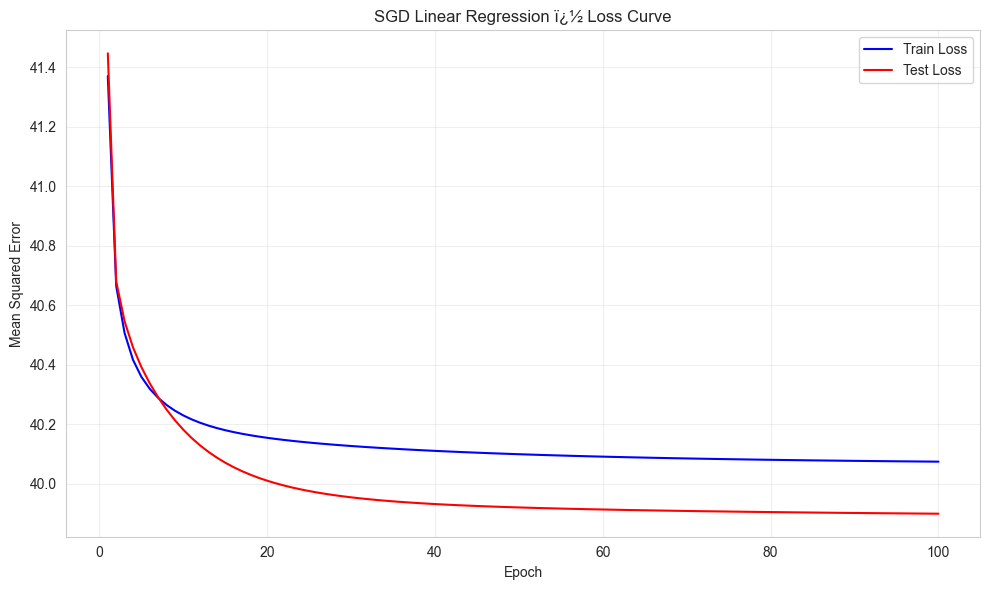

In [28]:
# loss curve shows how the error drops over training
plt.figure(figsize=(10, 6))
plt.plot(range(1, n_epochs + 1), train_losses, label='Train Loss', color='blue')
plt.plot(range(1, n_epochs + 1), test_losses, label='Test Loss', color='red')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.title('SGD Linear Regression � Loss Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('sgd_loss_curve.png', dpi=100, bbox_inches='tight')
plt.show()

The loss drops quickly in the first 10-20 epochs and then levels off  that's the model converging to a solution. Both train and test loss follow a similar path, which is a good sign (no overfitting). The SGD results are very close to the closed-form linear regression, which makes sense, they're solving the same problem, just using different methods.

### Decision Tree

In [29]:
# decision tree with max_depth=10 to prevent it from getting too complex
dt_model = DecisionTreeRegressor(random_state=42, max_depth=10)
dt_model.fit(X_train_scaled, y_train)
dt_results = evaluate_model(dt_model, X_train_scaled, X_test_scaled, y_train, y_test, 'Decision Tree')


--- Decision Tree ---
  Train MSE: 5.7222  |  Test MSE: 7.7125
  Train RMSE: 2.3921  |  Test RMSE: 2.7771
  Train MAE: 1.3513  |  Test MAE: 1.6575
  Train R2: 0.8856  |  Test R2: 0.8473


### Random Forest

In [30]:
# random forest  100 trees, should handle nonlinear patterns better
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_results = evaluate_model(rf_model, X_train_scaled, X_test_scaled, y_train, y_test, 'Random Forest')


--- Random Forest ---
  Train MSE: 0.3362  |  Test MSE: 1.8012
  Train RMSE: 0.5799  |  Test RMSE: 1.3421
  Train MAE: 0.3557  |  Test MAE: 0.8559
  Train R2: 0.9933  |  Test R2: 0.9643


Feature Importances (Random Forest):
  Labor_Force_Female_Pct                        0.1883 ##################
  Labor_Force_Total                             0.1784 #################
  Labor_Force_Basic_Education                   0.0513 #####
  Govt_Education_Spending_GDP_Pct               0.0505 #####
  Region_Encoded                                0.0442 ####
  Literacy_Rate_Male                            0.0440 ####
  Literacy_Rate_Female                          0.0372 ###
  Literacy_Rate_Adult                           0.0356 ###
  Primary_Teachers                              0.0350 ###
  Pupil_Teacher_Ratio_Primary                   0.0347 ###
  Labor_Force_Intermediate_Education            0.0306 ###
  School_Enrollment_Secondary                   0.0276 ##
  Secondary_Teachers                            0.0275 ##
  GDP_Per_Capita                                0.0253 ##
  Population_Total                              0.0247 ##
  Labor_Force_Advanced_Education               

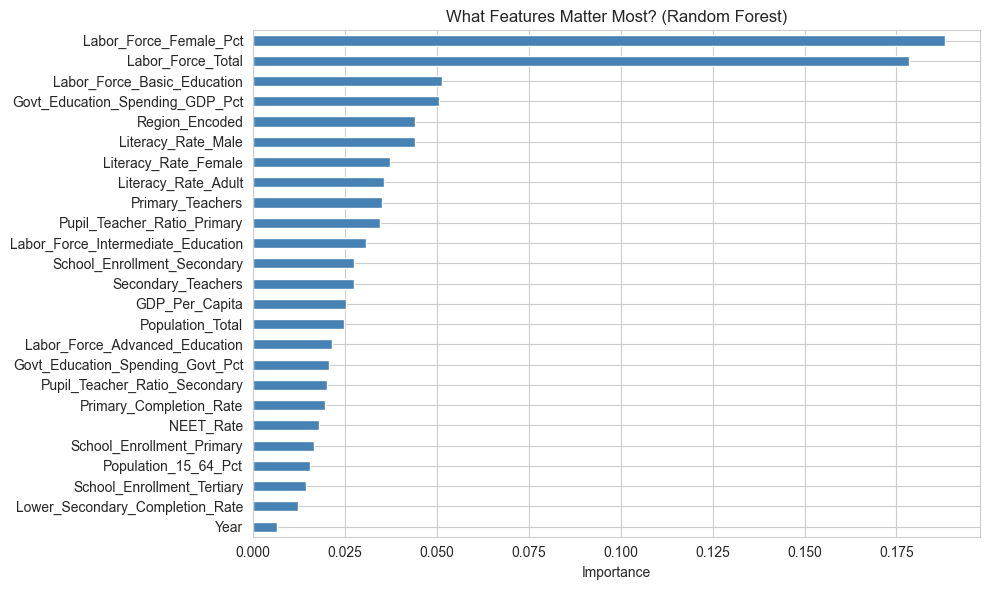

In [31]:
# what features does the random forest think are most important?
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

print('Feature Importances (Random Forest):')
print('=' * 55)
for feat, imp in importances.items():
    bar = '#' * int(imp * 100)
    print(f'  {feat:45s} {imp:.4f} {bar}')

plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='steelblue')
plt.xlabel('Importance')
plt.title('What Features Matter Most? (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importances.png', dpi=100, bbox_inches='tight')
plt.show()

This is interesting, the feature importances show which factors the Random Forest relies on most to predict unemployment. The top features give a sense of what really drives unemployment in developing countries, and it's a mix of economic and education factors.

## Comparing the Models

Let me put all the results side by side to see which model did best.

In [32]:
# build a comparison table
all_results = [lr_results, sgd_results, dt_results, rf_results]
comparison_df = pd.DataFrame(all_results)
comparison_df = comparison_df[['Model', 'Train_MSE', 'Test_MSE', 'Train_RMSE', 'Test_RMSE',
                                'Train_MAE', 'Test_MAE', 'Train_R2', 'Test_R2']]

print('Model Comparison:')
print('=' * 100)
print(comparison_df.to_string(index=False))

Model Comparison:
            Model  Train_MSE  Test_MSE  Train_RMSE  Test_RMSE  Train_MAE  Test_MAE  Train_R2  Test_R2
Linear Regression  39.526107 39.442849    6.286979   6.280354   4.546412  4.497345  0.209950 0.218895
    SGD Regressor  40.074016 39.899018    6.330404   6.316567   4.569795  4.533790  0.198999 0.209862
    Decision Tree   5.722211  7.712463    2.392114   2.777132   1.351251  1.657454  0.885624 0.847267
    Random Forest   0.336227  1.801208    0.579851   1.342091   0.355669  0.855883  0.993279 0.964330


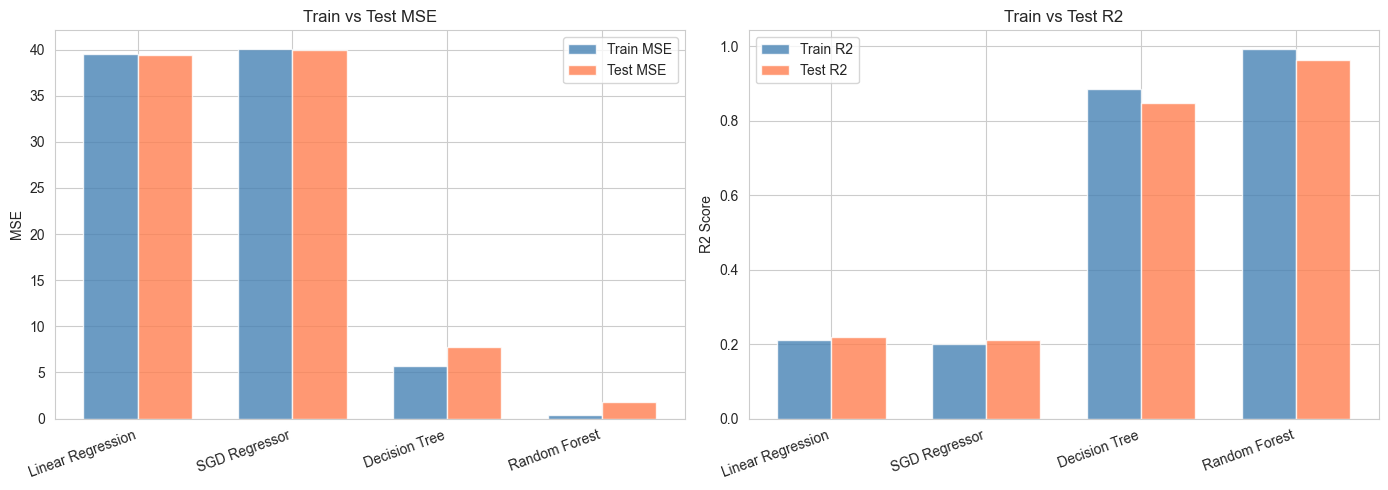

In [33]:
# visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = comparison_df['Model']
x = range(len(models))

# MSE comparison
axes[0].bar(x, comparison_df['Train_MSE'], width=0.35, label='Train MSE', color='steelblue', alpha=0.8)
axes[0].bar([i + 0.35 for i in x], comparison_df['Test_MSE'], width=0.35, label='Test MSE', color='coral', alpha=0.8)
axes[0].set_xticks([i + 0.175 for i in x])
axes[0].set_xticklabels(models, rotation=20, ha='right')
axes[0].set_ylabel('MSE')
axes[0].set_title('Train vs Test MSE')
axes[0].legend()

# R2 comparison
axes[1].bar(x, comparison_df['Train_R2'], width=0.35, label='Train R2', color='steelblue', alpha=0.8)
axes[1].bar([i + 0.35 for i in x], comparison_df['Test_R2'], width=0.35, label='Test R2', color='coral', alpha=0.8)
axes[1].set_xticks([i + 0.175 for i in x])
axes[1].set_xticklabels(models, rotation=20, ha='right')
axes[1].set_ylabel('R2 Score')
axes[1].set_title('Train vs Test R2')
axes[1].legend()

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

In [34]:
# save the best model (lowest test MSE)
best_idx = comparison_df['Test_MSE'].idxmin()
best_model_name = comparison_df.loc[best_idx, 'Model']
best_test_mse = comparison_df.loc[best_idx, 'Test_MSE']
best_test_r2 = comparison_df.loc[best_idx, 'Test_R2']

model_map = {
    'Linear Regression': lr_model,
    'SGD Regressor': sgd_model,
    'Decision Tree': dt_model,
    'Random Forest': rf_model
}
best_model = model_map[best_model_name]

joblib.dump(best_model, 'best_model.pkl')
print(f'Best model: {best_model_name}')
print(f'  Test MSE: {best_test_mse:.4f}')
print(f'  Test R2:  {best_test_r2:.4f}')
print(f'Saved as best_model.pkl')

Best model: Random Forest
  Test MSE: 1.8012
  Test R2:  0.9643
Saved as best_model.pkl


The Random Forest clearly wins, it has the lowest test MSE and highest R2 by a good margin. The tree-based models do much better than plain linear regression here, which suggests there are nonlinear relationships in the data that linear models can't capture. The Decision Tree is decent but the Random Forest's ensemble approach smooths out the noise.

## Visualizing the Results

### Actual vs Predicted

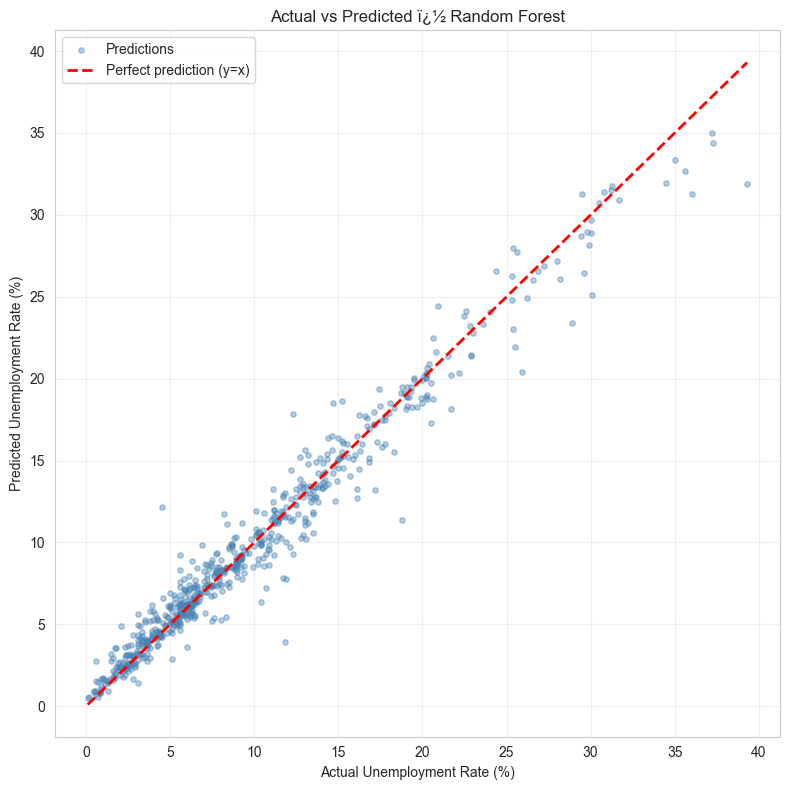

In [35]:
# scatter plot: actual vs predicted unemployment
y_test_pred = best_model.predict(X_test_scaled)

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_test_pred, alpha=0.4, s=15, color='steelblue', label='Predictions')

# diagonal = perfect predictions
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect prediction (y=x)')

plt.xlabel('Actual Unemployment Rate (%)')
plt.ylabel('Predicted Unemployment Rate (%)')
plt.title(f'Actual vs Predicted � {best_model_name}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=100, bbox_inches='tight')
plt.show()

The points cluster pretty close to the diagonal line, which means the model's predictions are generally accurate. There are some outliers � countries where the model over- or under-predicts � but overall the fit looks solid. The model handles the low-to-mid unemployment range best, which makes sense since that's where most of the data is.

### Linear Regression Line Through the Data

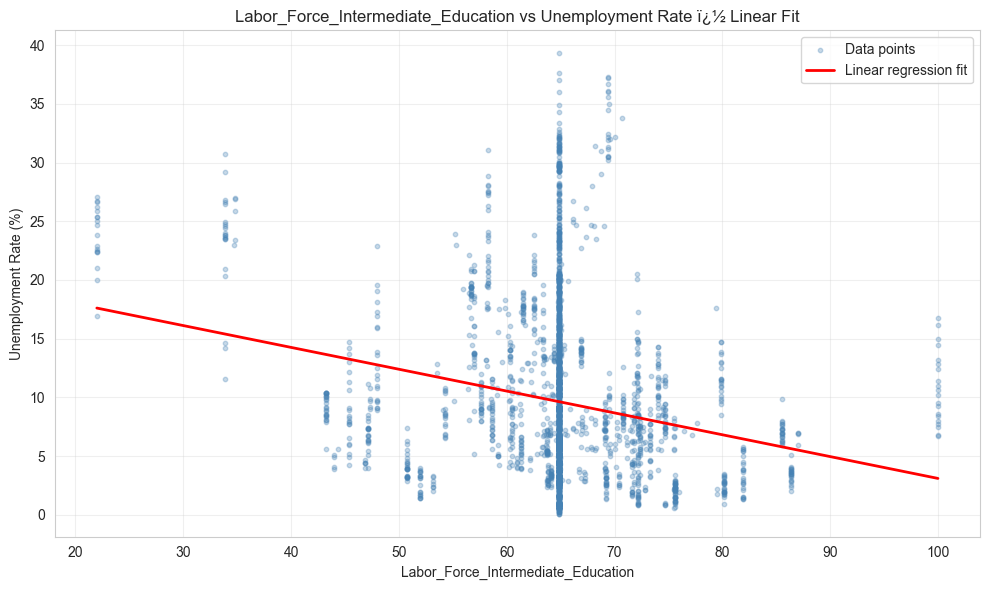

In [36]:
# pick the single most correlated feature and show the linear fit
top_feature = top_3_features[0]

plt.figure(figsize=(10, 6))
plt.scatter(df_clean[top_feature], df_clean['Unemployment_Rate'],
            alpha=0.3, s=10, color='steelblue', label='Data points')

# fit and draw a linear regression line
from numpy.polynomial.polynomial import polyfit
x_vals = df_clean[top_feature].values
y_vals = df_clean['Unemployment_Rate'].values
b, m = polyfit(x_vals, y_vals, 1)
x_line = np.linspace(x_vals.min(), x_vals.max(), 100)
plt.plot(x_line, b + m * x_line, color='red', linewidth=2, label='Linear regression fit')

plt.xlabel(top_feature)
plt.ylabel('Unemployment Rate (%)')
plt.title(f'{top_feature} vs Unemployment Rate � Linear Fit')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('linear_fit.png', dpi=100, bbox_inches='tight')
plt.show()

This shows how a simple linear regression line fits through the raw data for the most correlated feature. You can see the general trend, but there's a lot of spread around the line, which is exactly why using multiple features (multivariate regression) and nonlinear models like Random Forest gives much better predictions than a single-feature linear model.

## Making a Single Prediction

Let me grab one data point from the test set and see how the model does on it.

In [37]:
# pick one sample from the test set
sample_features = X_test.iloc[[0]]
sample_actual = y_test.iloc[0]

# scale it and predict
sample_scaled = scaler.transform(sample_features)
sample_prediction = best_model.predict(sample_scaled)[0]

print('Single Prediction Test')
print('=' * 50)
print('\nInput features:')
for col in sample_features.columns:
    print(f'  {col}: {sample_features[col].values[0]:.2f}')

print(f'\nPredicted unemployment rate: {sample_prediction:.2f}%')
print(f'Actual unemployment rate:    {sample_actual:.2f}%')
print(f'Error:                       {abs(sample_prediction - sample_actual):.2f}%')

Single Prediction Test

Input features:
  Year: 2013.00
  GDP_Per_Capita: 7674.86
  Literacy_Rate_Female: 97.98
  Literacy_Rate_Male: 98.75
  Literacy_Rate_Adult: 98.35
  Primary_Completion_Rate: 97.97
  Pupil_Teacher_Ratio_Primary: 17.63
  School_Enrollment_Primary: 99.37
  Primary_Teachers: 14388.00
  Lower_Secondary_Completion_Rate: 42.30
  Pupil_Teacher_Ratio_Secondary: 13.04
  School_Enrollment_Secondary: 98.88
  Secondary_Teachers: 39843.00
  School_Enrollment_Tertiary: 66.54
  Govt_Education_Spending_Govt_Pct: 11.44
  Govt_Education_Spending_GDP_Pct: 4.06
  Labor_Force_Advanced_Education: 73.49
  Labor_Force_Basic_Education: 24.93
  Labor_Force_Intermediate_Education: 62.00
  Labor_Force_Female_Pct: 46.65
  Labor_Force_Total: 3378735.00
  NEET_Rate: 24.70
  Population_15_64_Pct: 67.04
  Population_Total: 7265115.00
  Region_Encoded: 1.00

Predicted unemployment rate: 10.45%
Actual unemployment rate:    12.90%
Error:                       2.45%


In [38]:
# save feature names for predict.py
feature_names = X.columns.tolist()
joblib.dump(feature_names, 'feature_names.pkl')
print(f'Feature names saved ({len(feature_names)} features)')

Feature names saved (25 features)


---
That's the full pipeline
from raw World Bank data to trained models that can predict unemployment in developing countries. The Random Forest model came out on top, and the saved `.pkl` files can be used in `predict.py` for standalone predictions.